# 02. Land surface temperature with Sentinel-3

Sentinel-3 SLSTR measures land surface temperature (LST) at about 1 km, twice a day. This notebook runs the full Sentinel-3 path on real data over Berlin, August 2026:

1. one workflow call that discovers, downloads, quality-masks and grids every daytime pass;
2. what is inside the resulting cube, and how good each scene is;
3. maps, a gallery of clear scenes and a temperature time series;
4. summary statistics and heat-hazard indicators;
5. day versus night (the urban heat island);
6. writing results as Zarr, NetCDF, Cloud Optimized GeoTIFF, CSV and PNG, and reading them back;
7. the lower-level building blocks (catalogue, SAFE reader, gridding) and server-side processing with openEO.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import dotenv_values, load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "notebooks"
WORK = OUT / "work"  # shared download/subset cache: later notebooks reuse it
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Credentials live in the repository's .env (see docs/setup.md). The
# Earthdata token is often kept only in worker/.env; fall back to it.
load_dotenv(ROOT / ".env")
if not os.getenv("EARTHDATA_BEARER_TOKEN"):
    token = dotenv_values(ROOT / "worker" / ".env").get("EARTHDATA_BEARER_TOKEN")
    if token:
        os.environ["EARTHDATA_BEARER_TOKEN"] = token

# Upstream notices (numpy/xarray/matplotlib internals, all-NaN slices of
# cloudy scenes) that say nothing about the analysis.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "image.origin": "upper"})
pd.set_option("display.max_colwidth", 70)

In [2]:
def extent_km(da):
    """imshow extent of a projected y/x grid, in kilometres."""
    x, y = da["x"].values, da["y"].values
    dx, dy = abs(x[1] - x[0]), abs(y[1] - y[0])
    return [(x.min() - dx / 2) / 1e3, (x.max() + dx / 2) / 1e3, (y.min() - dy / 2) / 1e3, (y.max() + dy / 2) / 1e3]


def show_map(ax, da, title, cmap="inferno", label=None, vmin=None, vmax=None):
    """One georeferenced map with a colour bar; axes in UTM kilometres."""
    image = ax.imshow(da.values, extent=extent_km(da), cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("easting (km)")
    ax.set_ylabel("northing (km)")
    plt.colorbar(image, ax=ax, shrink=0.8, label=label or da.attrs.get("units", ""))
    return image

In [3]:
import dataclasses
import logging

import sentinel_analysis as sa

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
# openeo logs the OAuth client id of every token request at INFO level.
for noisy in ("httpx", "openeo"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

## 1. Run the workflow

`AnalysisRequest.for_city` builds a 1 km thermal grid for Berlin. With `thermal_overpass="day"` only the morning passes are used. `execute()` then, for each product:

* downloads only the five files the analysis needs (about 17 MB instead of 70 MB),
* crops the swath to the AOI and stores that subset under `WORK/subsets/` (a second run downloads nothing),
* applies the handbook quality screening: ESA's Bayesian cloud mask, unfilled, cosmetic and duplicate pixels, and views beyond 45 degrees,
* grids it onto the thermal grid by area-weighted averaging of each pixel's footprint,
* converts Kelvin to degrees Celsius.

In [4]:
berlin = sa.get_city("berlin")
request = sa.AnalysisRequest.for_city(berlin, "2026-08-01", "2026-08-21", sensors=("sentinel3",), max_products_per_sensor=30)
request = dataclasses.replace(request, thermal_overpass="day")

result = sa.AnalysisWorkflow(request).execute(WORK)
cube = result.thermal_cube
print(cube.sizes)
print("failed products:", result.provenance["failed_products"])

INFO sentinel_analysis.workflow.runner: sentinel3: 40 candidate products, 37 cover at least 30% of the AOI, 30 selected


INFO sentinel_analysis.workflow.runner: sentinel3: acquiring 30 products


INFO sentinel_analysis.workflow.runner: sentinel3: prepared 30 acquisitions


INFO sentinel_analysis.workflow.runner: Fused cube: 30 times, 15 variables


Frozen({'time': 30, 'y': 22, 'x': 25})
failed products: []


## 2. What is in the thermal cube

Besides `lst`, every cell keeps its uncertainty, the viewing angle, the quality flags and how many native pixels contributed to it, so any value can be traced back.

In [5]:
pd.DataFrame([
    {"variable": name, "dtype": str(var.dtype), "units": var.attrs.get("units", ""), "description": var.attrs.get("long_name", "")}
    for name, var in cube.data_vars.items()
])

,variable,dtype,units,description
0,lst,float32,degC,land surface temperature
1,lst_uncertainty,float32,K,
2,sat_zenith,float32,degree,
3,cloud_mask,float32,1,
4,exception_flags,int64,1,
5,cloud_flags,int64,1,
6,bayes_flags,int64,1,
7,confidence_flags,int64,1,
8,coverage_fraction,float32,1,
9,lst_observation_count,int32,1,


### Scene quality

A cell is usable when it was observed (`source_footprint_count > 0`) and passed the quality screening (`valid_mask`). Cloudy scenes are kept, not dropped: the time axis stays complete and the mask says what happened.

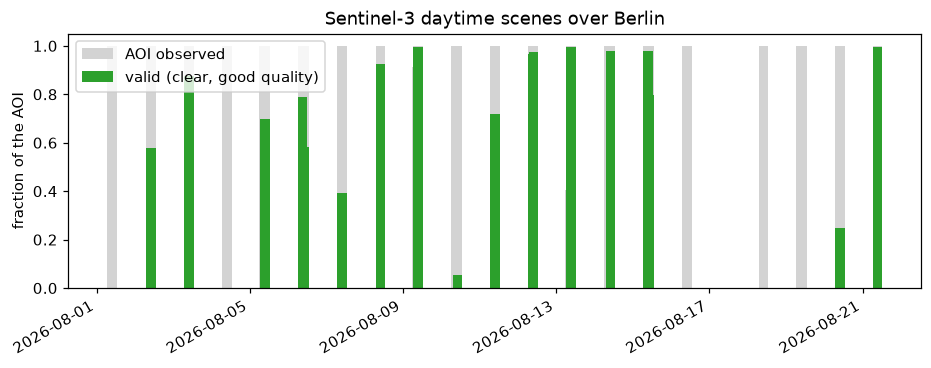

time,2026-08-01 09:40:27.271033,2026-08-02 10:16:35.048924,2026-08-03 09:50:23.896256,2026-08-04 09:24:12.723068,2026-08-04 10:02:53.420753,2026-08-05 08:58:01.566071,2026-08-05 09:36:42.351631,2026-08-06 09:10:31.310530,2026-08-06 10:12:49.598361,2026-08-07 09:46:38.736426,...,2026-08-14 09:03:02.665050,2026-08-14 10:05:21.004536,2026-08-15 09:39:10.065349,2026-08-15 10:17:50.953440,2026-08-16 09:51:40.009940,2026-08-18 10:01:36.450904,2026-08-19 09:35:25.463543,2026-08-19 10:14:06.347894,2026-08-20 09:47:55.355067,2026-08-21 09:21:44.351524
observed,1.0,1.00,1.00,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.0,1.0,1.0,1.0,1.00,1.0
valid,0.0,0.58,0.88,0.0,0.0,0.00,0.70,0.79,0.58,0.39,...,0.00,0.98,0.98,0.80,0.0,0.0,0.0,0.0,0.25,1.0
cloud,1.0,0.92,0.40,1.0,1.0,0.53,0.68,0.52,0.74,0.95,...,0.03,0.16,0.21,0.63,1.0,1.0,1.0,1.0,0.97,0.0


In [6]:
observed = (cube["source_footprint_count"] > 0).mean(["y", "x"])
valid = cube["valid_mask"].mean(["y", "x"])
cloud = (cube["cloud_mask"].fillna(0).astype(bool) & (cube["source_footprint_count"] > 0)).mean(["y", "x"])
scenes = pd.DataFrame({"observed": observed.values, "valid": valid.values, "cloud": cloud.values}, index=pd.DatetimeIndex(cube.time.values, name="time"))

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(scenes.index, scenes.observed, width=0.25, color="lightgrey", label="AOI observed")
ax.bar(scenes.index, scenes.valid, width=0.25, color="tab:green", label="valid (clear, good quality)")
ax.set_ylabel("fraction of the AOI")
ax.set_title("Sentinel-3 daytime scenes over Berlin")
ax.legend(loc="upper left")
fig.autofmt_xdate()
fig.savefig(FIGURES / "02_scene_quality.png", bbox_inches="tight")
plt.show()
scenes.round(2).T

### Choosing clear scenes before downloading them

Two request options decide which products are worth downloading at all:

* `min_aoi_coverage` (default 0.3) uses each product's catalogue footprint to drop passes that only graze the AOI. It costs nothing: the footprint comes with the search result.
* `min_clear_fraction` probes the clouds over the AOI. Catalogue cloud cover is for the whole 1500 km granule and says little about one city, so the workflow takes three times as many candidates, downloads only their geolocation, cloud mask and view geometry (about 14 MB each), and keeps those whose share of the AOI that is clear *and* seen at no more than 45 degrees reaches the threshold: a clear scene at the swath edge would otherwise be downloaded only to be screened out.

Here: the ten clearest daytime scenes, each at least half clear over Berlin.

In [7]:
clear_request = dataclasses.replace(request, max_products_per_sensor=10, min_clear_fraction=0.5)
clear_result = sa.AnalysisWorkflow(clear_request).execute(WORK)
clear_cube = clear_result.thermal_cube
print(f"kept {clear_cube.sizes['time']} scenes, {len(clear_result.provenance['probed_out'])} candidates rejected by the probe")
valid_kept = clear_cube["valid_mask"].mean(["y", "x"]).to_series()
pd.DataFrame({"all daytime scenes": scenes.valid.describe(), "probed, >= 50 % clear": valid_kept.describe()}).round(2).loc[["count", "mean", "min", "max"]]

INFO sentinel_analysis.workflow.runner: sentinel3: 40 candidate products, 37 cover at least 30% of the AOI, 30 selected


INFO sentinel_analysis.workflow.runner: sentinel3: acquiring 30 products


INFO sentinel_analysis.workflow.adapters: sentinel3: probed 19 candidates for clear sky over the AOI, kept 10


INFO sentinel_analysis.workflow.runner: sentinel3: prepared 10 acquisitions


INFO sentinel_analysis.workflow.runner: Fused cube: 10 times, 15 variables


kept 10 scenes, 9 candidates rejected by the probe


,all daytime scenes,"probed, >= 50 % clear"
count,30.00,10.00
mean,0.45,0.92
min,0.00,0.70
max,1.00,0.99


## 3. Maps

### One scene, layer by layer

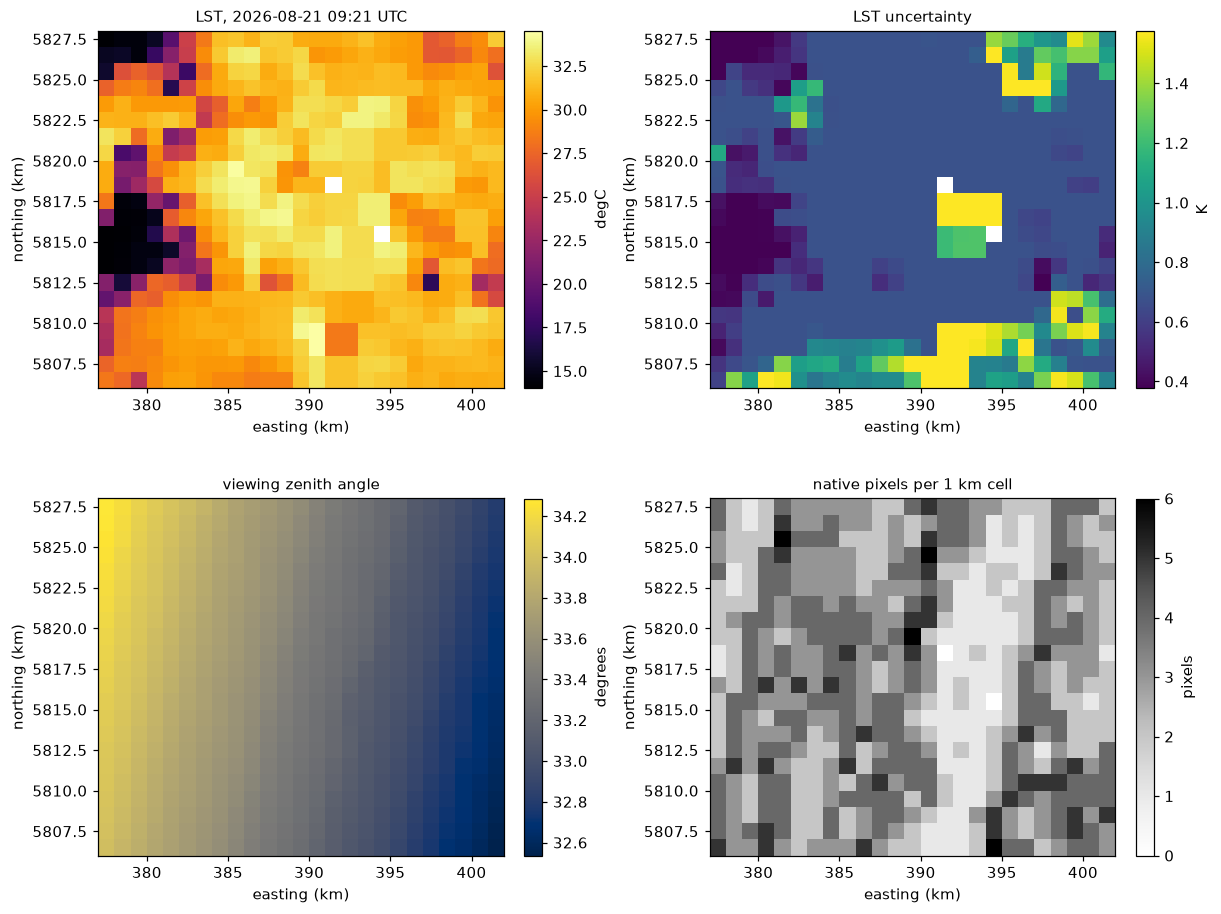

In [8]:
best = int(valid.argmax())
scene = cube.isel(time=best)
when = pd.Timestamp(scene.time.values).strftime("%Y-%m-%d %H:%M UTC")

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), constrained_layout=True)
show_map(axes[0, 0], scene["lst"], f"LST, {when}", cmap="inferno", label="degC")
show_map(axes[0, 1], scene["lst_uncertainty"], "LST uncertainty", cmap="viridis", label="K")
show_map(axes[1, 0], scene["sat_zenith"], "viewing zenith angle", cmap="cividis", label="degrees")
show_map(axes[1, 1], scene["lst_observation_count"], "native pixels per 1 km cell", cmap="Greys", label="pixels")
fig.savefig(FIGURES / "02_scene_layers.png", bbox_inches="tight")
plt.show()

### Every clear scene on one colour scale

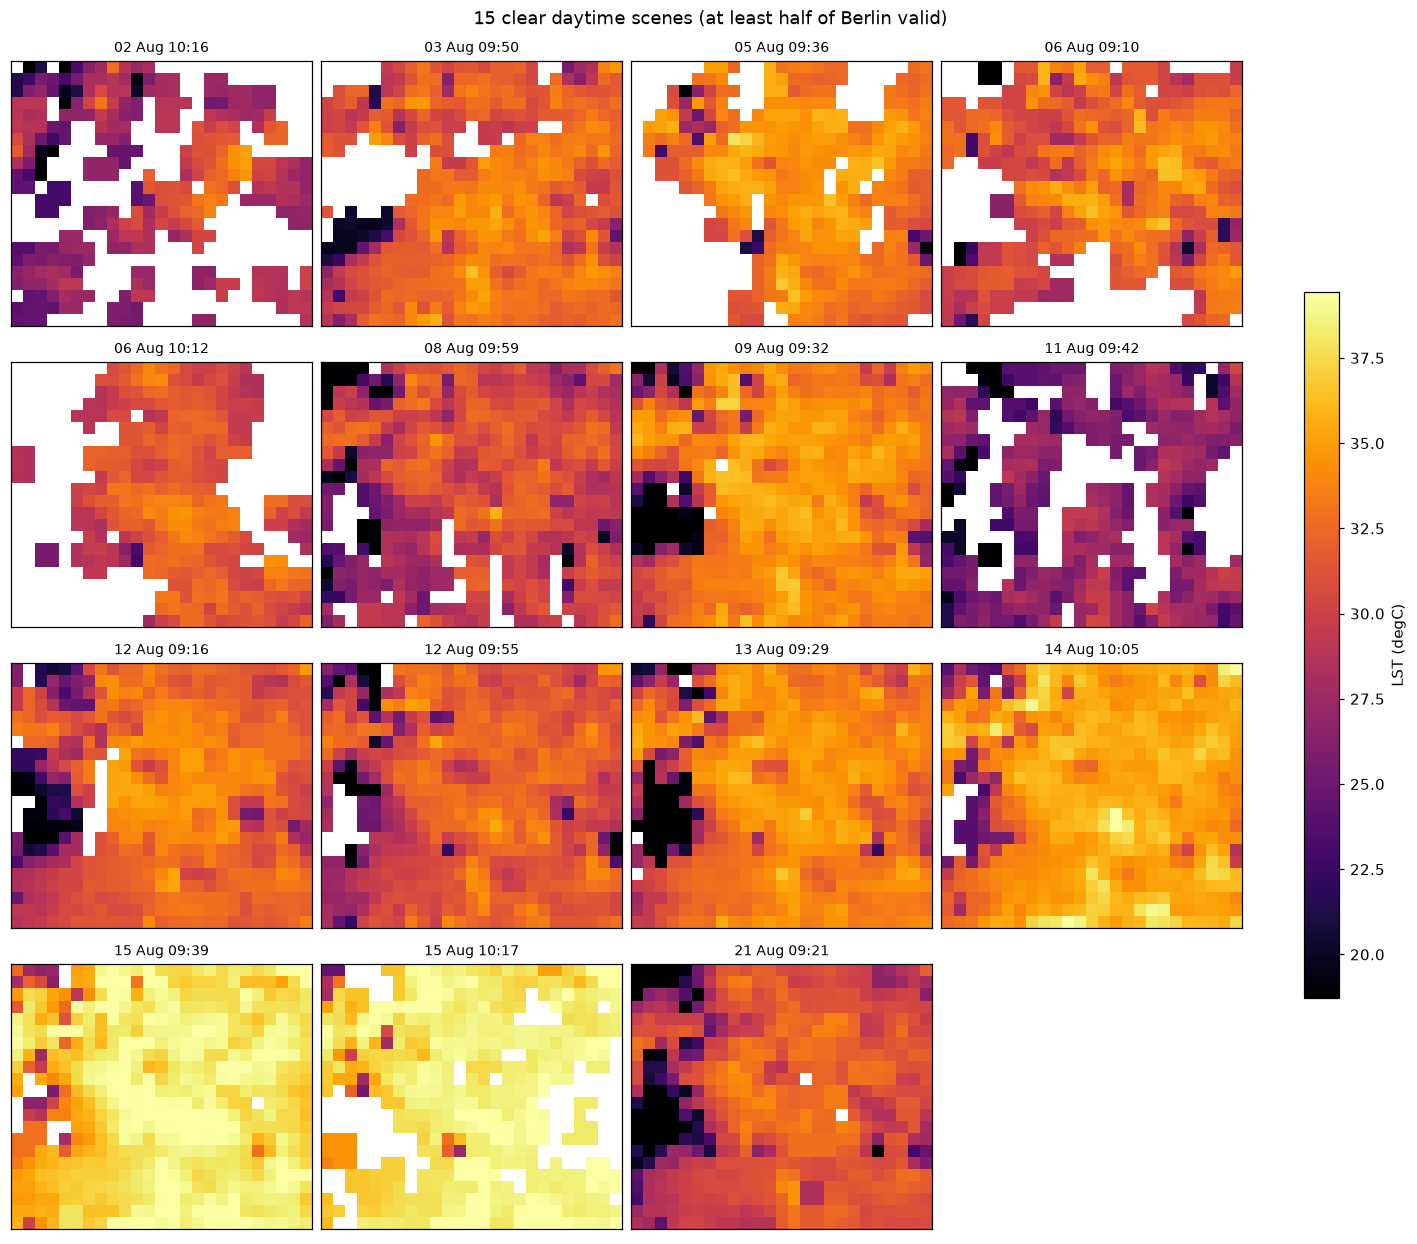

In [9]:
clear = cube.isel(time=np.flatnonzero(valid.values >= 0.5))
low, high = np.nanpercentile(clear["lst"].values, [2, 98])
columns = 4
rows = int(np.ceil(clear.sizes["time"] / columns))
fig, axes = plt.subplots(rows, columns, figsize=(3.2 * columns, 2.8 * rows), constrained_layout=True)
for ax, index in zip(axes.flat, range(clear.sizes["time"])):
    layer = clear["lst"].isel(time=index)
    image = ax.imshow(layer.values, extent=extent_km(layer), cmap="inferno", vmin=low, vmax=high)
    ax.set_title(pd.Timestamp(layer.time.values).strftime("%d %b %H:%M"), fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
for ax in list(axes.flat)[clear.sizes["time"]:]:
    ax.axis("off")
fig.colorbar(image, ax=axes, shrink=0.6, label="LST (degC)")
fig.suptitle(f"{clear.sizes['time']} clear daytime scenes (at least half of Berlin valid)")
fig.savefig(FIGURES / "02_clear_scenes.png", bbox_inches="tight")
plt.show()

## 4. Time series

The city-wide median per scene, with the interquartile range showing how much temperature varies across Berlin at that moment. Point colour is the valid fraction: medians from mostly cloudy scenes rest on few cells.

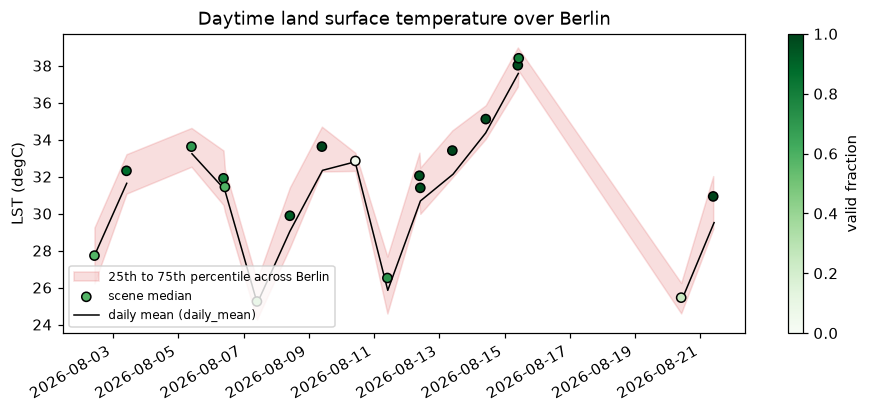

In [10]:
lst = cube["lst"]
series = pd.DataFrame({
    "median": lst.median(["y", "x"]).values,
    "p25": lst.quantile(0.25, ["y", "x"]).values,
    "p75": lst.quantile(0.75, ["y", "x"]).values,
    "valid": valid.values,
}, index=pd.DatetimeIndex(cube.time.values, name="time")).dropna(subset=["median"])

daily = sa.daily_mean(cube, assume_quality_masked=True)
daily_series = daily["lst"].mean(["y", "x"]).to_series()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(series.index, series.p25, series.p75, color="tab:red", alpha=0.15, label="25th to 75th percentile across Berlin")
points = ax.scatter(series.index, series["median"], c=series.valid, cmap="Greens", vmin=0, vmax=1, edgecolor="black", zorder=3, label="scene median")
ax.plot(pd.to_datetime(daily_series.index) + pd.Timedelta(hours=10), daily_series.values, color="black", lw=1, label="daily mean (daily_mean)")
ax.set_ylabel("LST (degC)")
ax.set_title("Daytime land surface temperature over Berlin")
plt.colorbar(points, ax=ax, label="valid fraction")
ax.legend(loc="lower left", fontsize=8)
fig.autofmt_xdate()
fig.savefig(FIGURES / "02_time_series.png", bbox_inches="tight")
plt.show()

## 5. Statistics and heat indicators

`statistics` summarises every valid observation. `heat_hazard_metrics` turns the stack into per-cell indicators: mean, 95th percentile, maximum, and how often each cell was at or above a threshold. Missing observations are never filled, so `observation_count` says how much evidence each cell has.

In [11]:
sa.statistics(cube)

{'pixels_total': 16500,
 'pixels_valid': 7449,
 'mean': 31.563922882080078,
 'median': 32.201995849609375,
 'min': 11.615997314453125,
 'max': 42.728973388671875}

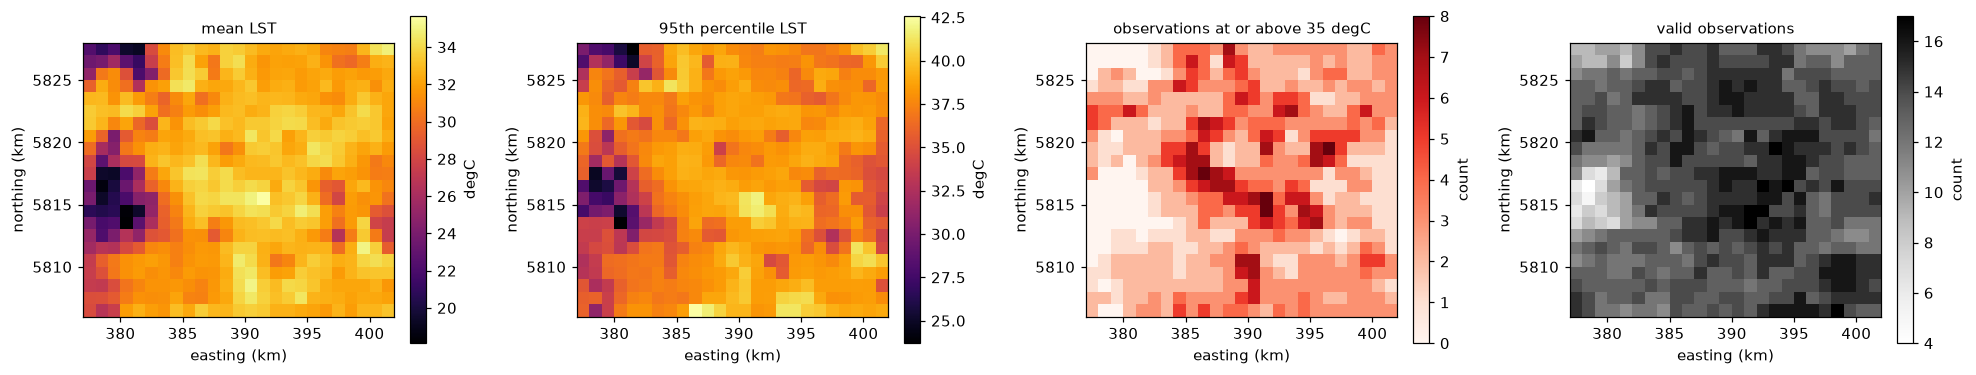

In [12]:
heat = sa.heat_hazard_metrics(cube, threshold_celsius=35.0)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), constrained_layout=True)
show_map(axes[0], heat["lst_mean"], "mean LST", label="degC")
show_map(axes[1], heat["lst_p95"], "95th percentile LST", label="degC")
show_map(axes[2], heat["hot_observation_count"], "observations at or above 35 degC", cmap="Reds", label="count")
show_map(axes[3], heat["observation_count"], "valid observations", cmap="Greys", label="count")
fig.savefig(FIGURES / "02_heat_metrics.png", bbox_inches="tight")
plt.show()

## 6. Day versus night

The same request with `thermal_overpass="night"` gives the evening passes. By day, the hottest surfaces are dry and sealed (roofs, rail yards, the airports); by night, the dense centre stays warmest because buildings release stored heat while vegetated and open areas cool down. That night-time contrast is the classic urban heat island.

INFO sentinel_analysis.workflow.runner: sentinel3: 41 candidate products, 39 cover at least 30% of the AOI, 30 selected


INFO sentinel_analysis.workflow.runner: sentinel3: acquiring 30 products


INFO sentinel_analysis.workflow.runner: sentinel3: prepared 30 acquisitions


INFO sentinel_analysis.workflow.runner: Fused cube: 30 times, 15 variables


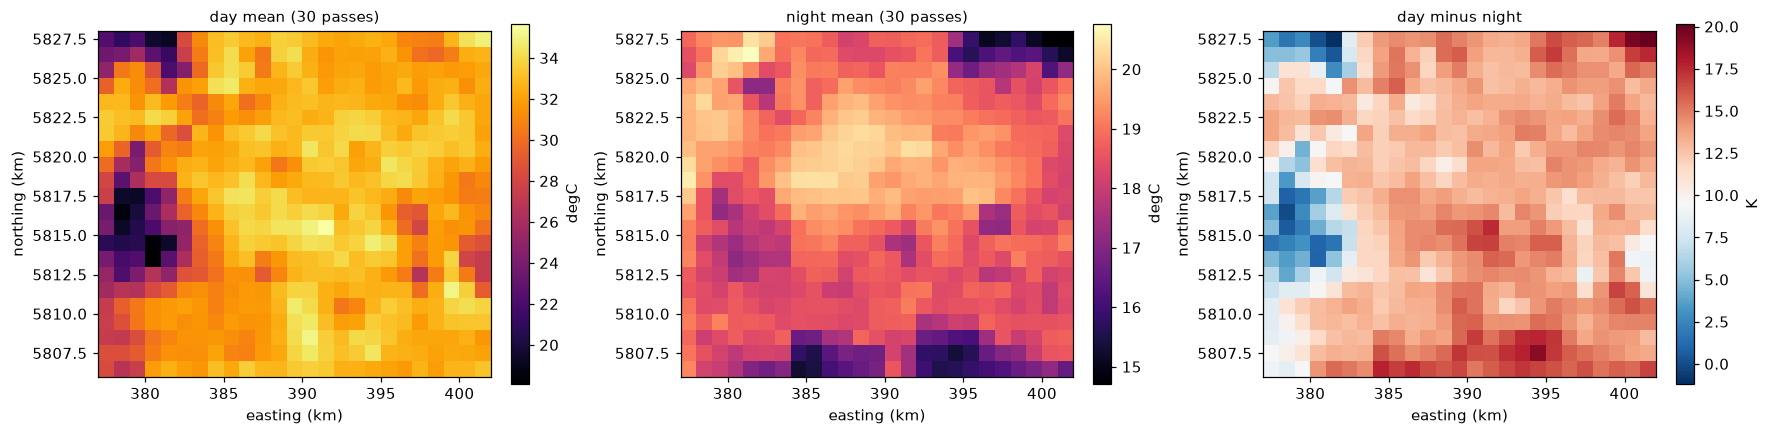

city-wide mean: day 31.2 degC, night 18.6 degC


In [13]:
night_request = dataclasses.replace(request, thermal_overpass="night")
night = sa.AnalysisWorkflow(night_request).execute(WORK).thermal_cube

day_mean = cube["lst"].mean("time")
night_mean = night["lst"].mean("time")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
show_map(axes[0], day_mean, f"day mean ({cube.sizes['time']} passes)", label="degC")
show_map(axes[1], night_mean, f"night mean ({night.sizes['time']} passes)", cmap="magma", label="degC")
show_map(axes[2], day_mean - night_mean, "day minus night", cmap="RdBu_r", label="K")
fig.savefig(FIGURES / "02_day_night.png", bbox_inches="tight")
plt.show()
print(f"city-wide mean: day {float(day_mean.mean()):.1f} degC, night {float(night_mean.mean()):.1f} degC")

## 7. Writing results

| Format | Function | Best for |
|---|---|---|
| Zarr | `result.save(dir)` or `sa.write_zarr` | whole cubes, lazy reading with `sa.open_zarr` |
| NetCDF | `sa.write_netcdf` (makes provenance attributes NetCDF-safe) | exchanging cubes with other tools |
| Cloud Optimized GeoTIFF | `sa.write_cog` | one map for GIS software (QGIS, ArcGIS) |
| CSV | pandas | tables and time series |
| PNG | matplotlib | figures |

`result.save` also writes `request.json` (to rerun the analysis) and `provenance.json` (sensors, failed products, software version and git commit).

In [14]:
export = OUT / "02_export"
saved = result.save(export / "result")
sa.write_netcdf(cube, export / "thermal_cube.nc")
cog = sa.write_cog(heat["lst_mean"].assign_attrs(crs=cube.attrs["crs"]), export / "berlin_mean_lst.tif")
series.to_csv(export / "berlin_lst_series.csv")

sizes = pd.DataFrame(
    [{"path": str(p.relative_to(export)), "MB": round(sum(f.stat().st_size for f in ([p] if p.is_file() else p.rglob("*") )) / 1e6, 2)}
     for p in sorted(export.iterdir()) + sorted(saved.iterdir())]
)
sizes

,path,MB
0,berlin_lst_series.csv,0.00
1,berlin_mean_lst.tif,0.00
2,result,0.51
3,thermal_cube.nc,1.12
4,result/cube.zarr,0.25
5,result/provenance.json,0.00
6,result/request.json,0.00
7,result/thermal_cube.zarr,0.25


In [15]:
import json
import rasterio

provenance = json.loads((saved / "provenance.json").read_text())
print("software:", provenance["software"])

reopened = sa.open_zarr(saved / "thermal_cube.zarr")  # lazy: nothing is read until needed
print(reopened["lst"])

with rasterio.open(cog) as source:
    print(source.profile["driver"], source.crs, source.res, "overviews:", source.overviews(1))

software: {'git_commit': 'c629cfd17920f30d0e115813cdf9be6929b12759', 'git_dirty': True, 'version': '0.2.0'}


<xarray.DataArray 'lst' (time: 30, y: 22, x: 25)> Size: 66kB
dask.array<open_dataset-lst, shape=(30, 22, 25), dtype=float32, chunksize=(30, 22, 25), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) float64 200B 3.775e+05 3.785e+05 ... 4.005e+05 4.015e+05
  * y        (y) float64 176B 5.828e+06 5.826e+06 ... 5.808e+06 5.806e+06
  * time     (time) datetime64[ns] 240B 2026-08-01T09:40:27.271033 ... 2026-0...
Attributes:
    units:                 degC
    standard_name:         surface_temperature
    sensor:                Sentinel-3
    product:               SL_2_LST
    aggregation_method:    area_weighted
    uncertainty_variable:  
    quality_variable:      valid_mask
    footprint:             pixel
    variable_role:         target
    long_name:             land surface temperature
GTiff EPSG:32633 (1000.0, 1000.0) overviews: []


## 8. Lower-level building blocks

The workflow is built from parts you can use directly.

### Catalogue, SAFE reader and gridding

`Sentinel3LST` is a small facade over the CDSE catalogue and downloader. Here we fetch one complete product (about 70 MB), inspect its layout, read it, and grid it by hand. The result matches the workflow's own scene exactly.

In [16]:
facade = sa.Sentinel3LST.from_cdse()
# The same acquisition as the clearest workflow scene shown in section 3.
target = pd.Timestamp(cube.time.values[best]).tz_localize("UTC")
day_products = facade.search(berlin.aoi, target.strftime("%Y-%m-%d"), target.strftime("%Y-%m-%d"))
product = min(day_products, key=lambda p: abs(pd.Timestamp(p.start_datetime) - target))
archive = facade.download(product, OUT / "02_raw")
print(product.name, f"{archive.stat().st_size / 1e6:.0f} MB")

layout = sa.inspect_l2_lst(archive)
{key: layout[key] for key in list(layout)[:6]}

S3A_SL_2_LST____20260821T092144_20260821T092444_20260822T214337_0179_143_093_1980_PS1_O_NT_005.SEN3 76 MB


{'metadata': ProductMetadata(product_name='S3A_SL_2_LST____20260821T092144_20260821T092444_20260822T214337_0179_143_093_1980_PS1_O_NT_005.SEN3', baseline='005', start_datetime='2026-08-21T09:21:44.351524Z', end_datetime='2026-08-21T09:24:44.351524Z', manifest=PosixPath('/tmp/sentinel-analysis-sentinel3-glayjlay/S3A_SL_2_LST____20260821T092144_20260821T092444_20260822T214337_0179_143_093_1980_PS1_O_NT_005.SEN3/xfdumanifest.xml')),
 'files': {'LST_in.nc': ['LST',
   'LST_orphan',
   'LST_uncertainty',
   'LST_uncertainty_orphan',
   'exception',
   'exception_orphan'],
  'flags_in.nc': ['bayes_in',
   'bayes_orphan_in',
   'cloud_in',
   'cloud_orphan_in',
   'confidence_in',
   'confidence_orphan_in',
   'counter_water_in',
   'counter_water_orphan_in',
   'pointing_in',
   'pointing_orphan_in'],
  'geodetic_in.nc': ['elevation_in',
   'elevation_orphan_in',
   'latitude_in',
   'latitude_orphan_in',
   'longitude_in',
   'longitude_orphan_in'],
  'geometry_tn.nc': ['sat_azimuth_tn',
  

In [17]:
swath = sa.read_l2_lst(archive, aoi=berlin.aoi)  # native swath, cropped to the AOI
print(swath.sizes)
thermal_grid = request.thermal_grid
manual = sa.to_celsius(sa.grid_l2_lst(sa.apply_quality_mask(swath), thermal_grid))
workflow_scene = cube["lst"].isel(time=best).values
difference = np.abs(manual["lst"].isel(time=0).values - workflow_scene)
print(f"{np.isfinite(difference).sum()} cells compared, largest difference {np.nanmax(difference):.6f} K")

Frozen({'time': 1, 'y': 49, 'x': 45})
548 cells compared, largest difference 0.000000 K


### Server-side processing with openEO

`Sentinel3LSTClient` builds the processing graph on the Copernicus openEO backend instead: only the requested area, dates and bands are processed there, and only the result is downloaded. It suits long periods or large areas where downloading products is not worth it. It needs the CDSE OAuth client credentials.

<xarray.Dataset> Size: 14kB
Dimensions:  (t: 4, x: 40, y: 21)
Coordinates:
  * t        (t) datetime64[ns] 32B 2026-08-09T08:54:00 ... 2026-08-09T20:58:00
  * x        (x) float64 320B 13.2 13.21 13.22 13.23 ... 13.53 13.53 13.54 13.55
  * y        (y) float64 168B 52.58 52.57 52.56 52.55 ... 52.42 52.41 52.41 52.4
Data variables:
    crs      |S1 1B ...
    LST      (t, y, x) float32 13kB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


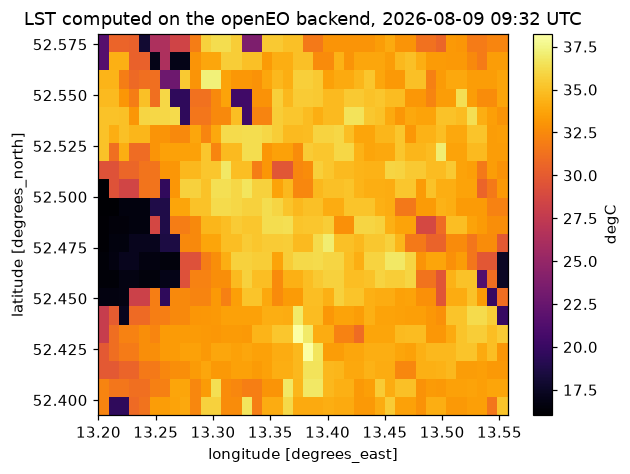

In [18]:
client = sa.Sentinel3LSTClient.from_env(ROOT / ".env")
remote = client.processed_cube(berlin.aoi, ["2026-08-09", "2026-08-10"])
remote_path = OUT / "02_openeo_lst.nc"
remote.download(remote_path)

with xr.open_dataset(remote_path) as remote_cube:
    print(remote_cube)
    variable = next(name for name in remote_cube.data_vars if name.upper() == "LST")
    stack = remote_cube[variable]
    time_dim = stack.dims[0]
    clearest = int(stack.notnull().sum([d for d in stack.dims if d != time_dim]).argmax())
    layer = stack.isel({time_dim: clearest})
    fig, ax = plt.subplots(figsize=(6, 4.5))
    layer.plot(ax=ax, cmap="inferno", cbar_kwargs={"label": "degC"})
    ax.set_title(f"LST computed on the openEO backend, {pd.Timestamp(layer[time_dim].values):%Y-%m-%d %H:%M} UTC")
    plt.show()

## Next

[03 Multisensor fusion](03_multisensor_fusion.ipynb) adds Sentinel-2, Sentinel-1, Sentinel-5P, Landsat, ECOSTRESS, weather, air quality and terrain on top of this thermal cube.